In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df = pd.read_csv('../Sample - Superstore.csv', encoding='latin1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHead:")
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Head:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


C:\Users\maimi\AppData\Local\Temp\ipykernel_31624\3603354135.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_d')


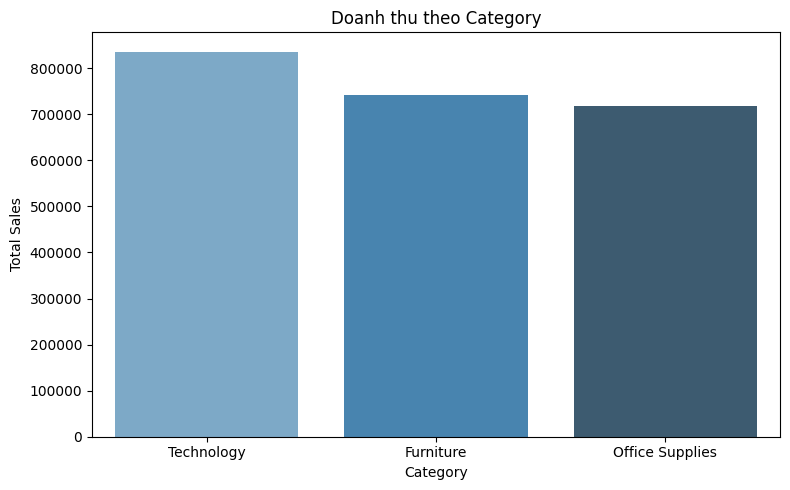

C:\Users\maimi\AppData\Local\Temp\ipykernel_31624\3603354135.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Greens_d')


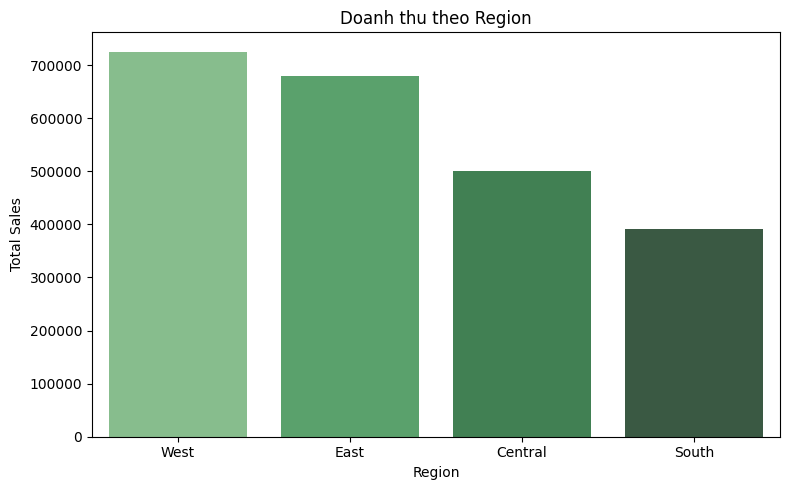

In [9]:
# Chuyển Order Date sang datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 1. Doanh thu theo Category
plt.figure(figsize=(8,5))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_d')
plt.title('Doanh thu theo Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('../dashboard/chart_category_sales.png')
plt.show()

# 2. Doanh thu theo Region
plt.figure(figsize=(8,5))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Greens_d')
plt.title('Doanh thu theo Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('../dashboard/chart_region_sales.png')
plt.show()

In [10]:
# Ngày tham chiếu = ngày cuối cùng trong dataset + 1
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)

# Tính RFM
rfm = df.groupby('Customer ID').agg(
    CustomerName = ('Customer Name', 'first'),
    Recency      = ('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency    = ('Order ID', 'nunique'),
    Monetary     = ('Sales', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print("RFM Shape:", rfm.shape)
rfm.head(10)

RFM Shape: (793, 5)


,Customer ID,CustomerName,Recency,Frequency,Monetary
0,AA-10315,Alex Avila,185,5,5563.56
1,AA-10375,Allen Armold,20,9,1056.39
2,AA-10480,Andrew Allen,260,4,1790.51
3,AA-10645,Anna Andreadi,56,6,5086.93
4,AB-10015,Aaron Bergman,416,3,886.16
5,AB-10060,Adam Bellavance,55,8,7755.62
6,AB-10105,Adrian Barton,42,10,14473.57
7,AB-10150,Aimee Bixby,42,5,966.71
8,AB-10165,Alan Barnes,26,8,1113.84
9,AB-10255,Alejandro Ballentine,167,9,914.53


In [11]:
# Tính điểm R, F, M (1-4)
rfm['R_score'] = pd.qcut(rfm['Recency'],  q=4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

# Tổng điểm RFM
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Phân nhóm khách hàng
def segment(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal'
    elif r >= 3 and f == 1:
        return 'New Customers'
    elif r == 2 and f >= 2:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

print("Phân bố segment:")
print(rfm['Segment'].value_counts())
rfm.head(10)

Phân bố segment:
Segment
Lost             231
Champions        176
At Risk          165
Loyal            149
New Customers     72
Name: count, dtype: int64


,Customer ID,CustomerName,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,AA-10315,Alex Avila,185,5,5563.56,1,1,4,114,Lost
1,AA-10375,Allen Armold,20,9,1056.39,4,4,1,441,Loyal
2,AA-10480,Andrew Allen,260,4,1790.51,1,1,2,112,Lost
3,AA-10645,Anna Andreadi,56,6,5086.93,3,2,4,324,Loyal
4,AB-10015,Aaron Bergman,416,3,886.16,1,1,1,111,Lost
5,AB-10060,Adam Bellavance,55,8,7755.62,3,3,4,334,Champions
6,AB-10105,Adrian Barton,42,10,14473.57,3,4,4,344,Champions
7,AB-10150,Aimee Bixby,42,5,966.71,3,1,1,311,New Customers
8,AB-10165,Alan Barnes,26,8,1113.84,4,3,1,431,Loyal
9,AB-10255,Alejandro Ballentine,167,9,914.53,2,4,1,241,At Risk


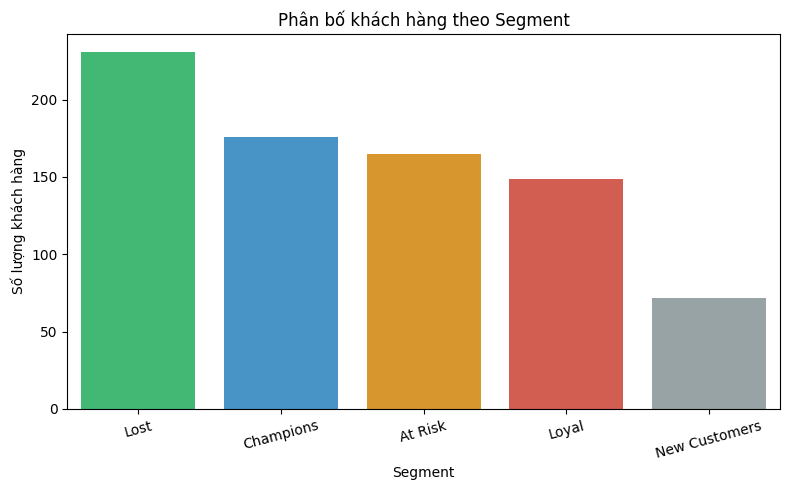

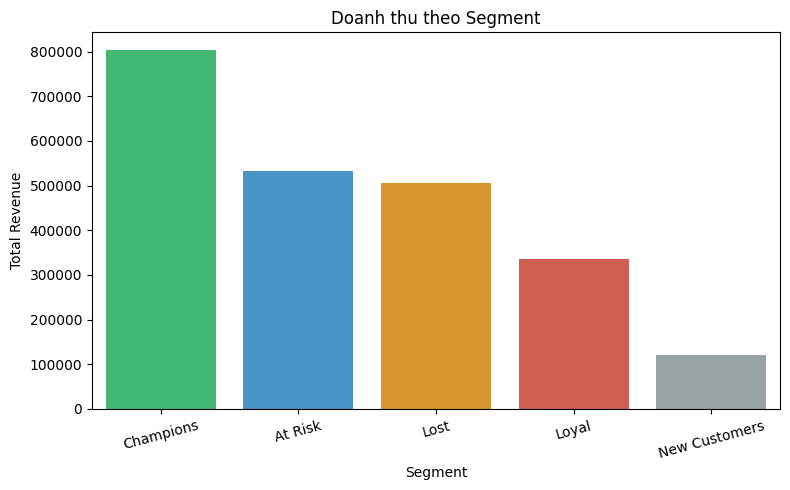

In [12]:
# Biểu đồ 1: Số lượng từng segment
plt.figure(figsize=(8,5))
segment_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6']
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette=colors, hue=segment_counts.index, legend=False)
plt.title('Phân bố khách hàng theo Segment')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../dashboard/chart_rfm_segment.png')
plt.show()

# Biểu đồ 2: Doanh thu từng segment
plt.figure(figsize=(8,5))
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
sns.barplot(x=segment_revenue.index, y=segment_revenue.values, palette=colors, hue=segment_revenue.index, legend=False)
plt.title('Doanh thu theo Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../dashboard/chart_rfm_revenue.png')
plt.show()

In [13]:
# Lưu kết quả RFM ra CSV
rfm.to_csv('../dashboard/rfm_result.csv', index=False)

print("✅ Đã lưu rfm_result.csv!")
print(f"Tổng số khách hàng: {len(rfm)}")
print(f"\nTổng doanh thu: ${rfm['Monetary'].sum():,.2f}")
print(f"\nTop 5 Champions:")
print(rfm[rfm['Segment']=='Champions'].sort_values('Monetary', ascending=False)[['CustomerName','Recency','Frequency','Monetary']].head())

✅ Đã lưu rfm_result.csv!
Tổng số khách hàng: 793

Tổng doanh thu: $2,297,200.88

Top 5 Champions:
      CustomerName  Recency  Frequency  Monetary
6    Adrian Barton       42         10  14473.57
434   Ken Lonsdale       48         12  14175.23
683   Sanjit Engle       10         11  12209.44
764   Todd Sumrall       37          6  11891.75
311      Greg Tran       37         11  11820.12
